# 06. Trích xuất đặc trưng đồ thị (Graph Feature Engineering)

New topic: Social network anomaly account detection using Isolation Forest with graph features. This notebook extends the old clustering project while keeping notebooks 01-05 as baselines.


## 1. Import thư viện và thiết lập đường dẫn

The dataset has no direct user-user edge. The graph is built from feature similarity, hashtag similarity, and interaction similarity.


In [1]:
import ast
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../datasets")
RESULTS_DIR = Path("../results")
FIGURE_DIR = RESULTS_DIR / "figures"
PROCESSED_DIR = DATA_DIR / "processed"

CLEAN_PATH = DATA_DIR / "cleaned" / "bot_detection_clean.csv"
FEATURES_WITH_LABEL_PATH = PROCESSED_DIR / "user_features_with_label.csv"
SCALED_FEATURES_PATH = PROCESSED_DIR / "user_features_scaled.csv"
GRAPH_FEATURES_PATH = PROCESSED_DIR / "user_graph_features.csv"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Tải dữ liệu đã tiền xử lý từ pipeline cũ

This notebook reuses `bot_detection_clean.csv`, `user_features_scaled.csv`, and `user_features_with_label.csv` from notebook 02.


In [2]:
df_clean = pd.read_csv(CLEAN_PATH)
df_scaled = pd.read_csv(SCALED_FEATURES_PATH)
df_users = pd.read_csv(FEATURES_WITH_LABEL_PATH)

print("Clean shape:", df_clean.shape)
print("Scaled feature shape:", df_scaled.shape)
print("Feature with label shape:", df_users.shape)

df_users.head()


Clean shape: (50000, 16)
Scaled feature shape: (50000, 9)
Feature with label shape: (50000, 11)


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label
0,132131,85,1,2353,0,83,5,0,0,1114,1
1,289683,55,5,9617,1,77,14,2,1,186,0
2,779715,6,2,4363,1,61,10,2,1,296,0
3,696168,54,5,2242,1,49,6,4,1,654,1
4,704441,26,3,8438,0,29,6,2,1,1142,1


In [3]:
required_user_cols = {"user_id", "mention_count", "retweet_count", "hashtag_count"}
missing_cols = required_user_cols - set(df_users.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in user_features_with_label.csv: {missing_cols}")

if len(df_users) != len(df_scaled):
    raise ValueError("Row count mismatch between old features and scaled features.")

user_ids = df_users["user_id"].astype(str).to_numpy()
print("Number of user nodes:", len(user_ids))


Number of user nodes: 50000


## 3. Xây dựng đồ thị tương tác mạng xã hội

Each user is a node. Edges are created from cosine similarity, hashtag overlap, and interaction similarity.


In [4]:
def add_or_update_edge(graph, u, v, weight, source):
    if u == v:
        return
    if graph.has_edge(u, v):
        graph[u][v]["weight"] = max(graph[u][v].get("weight", 0.0), float(weight))
        graph[u][v]["source"] = graph[u][v].get("source", "") + ";" + source
    else:
        graph.add_edge(u, v, weight=float(weight), source=source)

G = nx.Graph()
G.add_nodes_from(user_ids)
print("Initialized graph:", G.number_of_nodes(), "nodes")


Initialized graph: 50000 nodes


In [5]:
# Build this step from the available dataset fields.
# Build this step from the available dataset fields.
feature_top_k = 5
nn = NearestNeighbors(n_neighbors=feature_top_k + 1, metric="cosine", algorithm="brute")
nn.fit(df_scaled.values)
distances, indices = nn.kneighbors(df_scaled.values)

for row_idx, neighbor_indices in enumerate(indices):
    u = user_ids[row_idx]
    for pos, neighbor_idx in enumerate(neighbor_indices[1:], start=1):
        v = user_ids[neighbor_idx]
        similarity = 1 - distances[row_idx][pos]
        add_or_update_edge(G, u, v, similarity, "feature_similarity")

print("Sau feature similarity:", G.number_of_edges(), "edges")


Sau feature similarity: 159217 edges


In [6]:
# 3.2. Hashtag similarity edges
# Build this step from the available dataset fields.
# Build this step from the available dataset fields.
def tokenize_hashtags(value):
    if pd.isna(value):
        return []
    text = str(value).lower()
    tokens = re.findall(r"[a-zA-Z0-9_]+", text)
    return [token for token in tokens if len(token) > 2]

hashtag_series = df_clean.get("hashtags", pd.Series([""] * len(df_clean))).apply(tokenize_hashtags)
hashtag_to_users = {}
for uid, tokens in zip(user_ids, hashtag_series):
    for token in set(tokens):
        hashtag_to_users.setdefault(token, []).append(uid)

max_users_per_hashtag = 25
for token, users in hashtag_to_users.items():
    if len(users) < 2:
        continue
    selected_users = users[:max_users_per_hashtag]
    for i in range(len(selected_users) - 1):
        add_or_update_edge(G, selected_users[i], selected_users[i + 1], 0.75, "hashtag_similarity")

print("Sau hashtag similarity:", G.number_of_edges(), "edges")


Sau hashtag similarity: 181823 edges


In [7]:
# Build this step from the available dataset fields.
interaction_cols = ["mention_count", "retweet_count", "hashtag_count"]
interaction_matrix = df_users[interaction_cols].fillna(0).values
interaction_top_k = 3
interaction_nn = NearestNeighbors(n_neighbors=interaction_top_k + 1, metric="cosine", algorithm="brute")
interaction_nn.fit(interaction_matrix)
interaction_distances, interaction_indices = interaction_nn.kneighbors(interaction_matrix)

for row_idx, neighbor_indices in enumerate(interaction_indices):
    u = user_ids[row_idx]
    for pos, neighbor_idx in enumerate(neighbor_indices[1:], start=1):
        v = user_ids[neighbor_idx]
        similarity = 1 - interaction_distances[row_idx][pos]
        add_or_update_edge(G, u, v, similarity, "interaction_similarity")

print("Final graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 6))


Final graph:
Nodes: 50000
Edges: 313157
Density: 0.000251


## 4. Tính toán các đặc trưng đồ thị

Generated features: `degree`, `degree_centrality`, `clustering_coefficient`, `interaction_score`, and `pagerank`.


In [8]:
degree_dict = dict(G.degree())
degree_centrality = nx.degree_centrality(G)
clustering_coefficient = nx.clustering(G)
pagerank = nx.pagerank(G, weight="weight", alpha=0.85, max_iter=100)
weighted_degree = dict(G.degree(weight="weight"))

weighted_values = np.array([weighted_degree.get(uid, 0.0) for uid in user_ids]).reshape(-1, 1)
interaction_score = MinMaxScaler().fit_transform(weighted_values).ravel()

graph_features = pd.DataFrame({
    "user_id": df_users["user_id"].values,
    "degree": [degree_dict.get(uid, 0) for uid in user_ids],
    "degree_centrality": [degree_centrality.get(uid, 0.0) for uid in user_ids],
    "clustering_coefficient": [clustering_coefficient.get(uid, 0.0) for uid in user_ids],
    "interaction_score": interaction_score,
    "pagerank": [pagerank.get(uid, 0.0) for uid in user_ids],
})

graph_features.head()


,user_id,degree,degree_centrality,clustering_coefficient,interaction_score,pagerank
0,132131,11,0.00022,0.145455,0.004391,0.000019
1,289683,10,0.00020,0.177778,0.003366,0.000016
2,779715,9,0.00018,0.166667,0.002577,0.000014
3,696168,13,0.00026,0.102564,0.005319,0.000020
4,704441,11,0.00022,0.127273,0.004037,0.000017


In [9]:
graph_features.describe().T


,count,mean,std,min,25%,50%,75%,max
user_id,50000.0,548890.680540,259756.681425,100025.00000,323524.250000,548147.000000,772983.000000,999995.000000
degree,50000.0,12.526280,12.430981,6.00000,9.000000,10.000000,14.000000,1362.000000
degree_centrality,50000.0,0.000251,0.000249,0.00012,0.000180,0.000200,0.000280,0.027241
clustering_coefficient,50000.0,0.176800,0.092826,0.00000,0.128205,0.166667,0.214286,0.964286
interaction_score,50000.0,0.005356,0.009092,0.00000,0.002883,0.003650,0.005862,1.000000
pagerank,50000.0,0.000020,0.000019,0.00001,0.000015,0.000017,0.000021,0.002085


## 5. Lưu đặc trưng đồ thị


In [10]:
graph_features.to_csv(GRAPH_FEATURES_PATH, index=False)
print("Saved:", GRAPH_FEATURES_PATH)
print("Shape:", graph_features.shape)


Saved: ..\datasets\processed\user_graph_features.csv
Shape: (50000, 6)


## 6. Trực quan hóa đặc trưng đồ thị


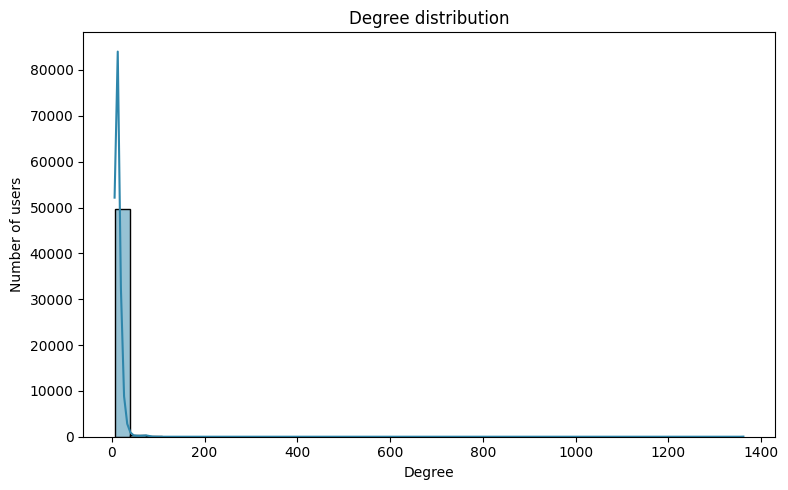

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(graph_features["degree"], bins=40, kde=True, color="#2E86AB")
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Number of users")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "graph_degree_distribution.png", dpi=150)
plt.show()


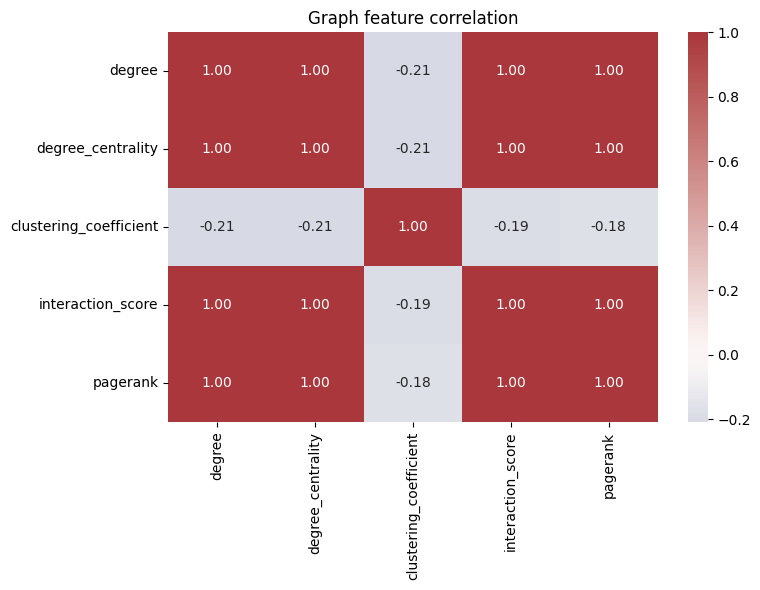

In [12]:
corr = graph_features.drop(columns=["user_id"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Graph feature correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "graph_feature_correlation.png", dpi=150)
plt.show()


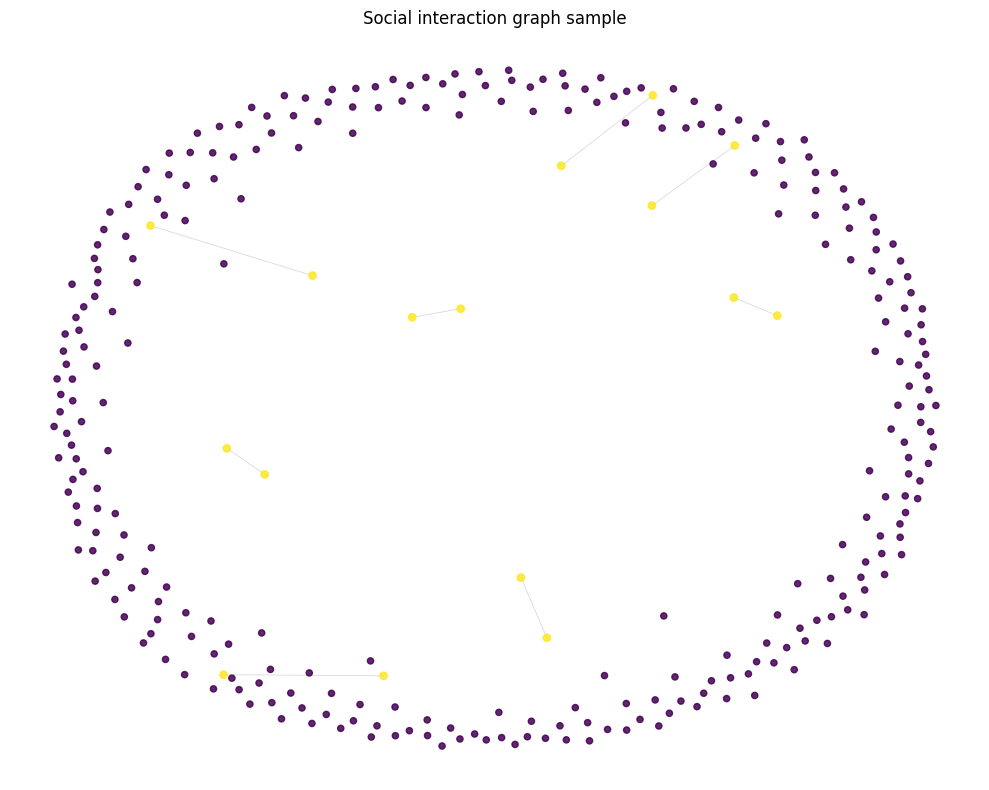

In [13]:
# Build this step from the available dataset fields.
sample_size = min(300, G.number_of_nodes())
rng = np.random.default_rng(RANDOM_STATE)
sampled_nodes = rng.choice(user_ids, size=sample_size, replace=False)
G_sample = G.subgraph(sampled_nodes).copy()

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sample, seed=RANDOM_STATE, k=0.35)
node_degree = np.array([G_sample.degree(node) for node in G_sample.nodes()])
node_size = 20 + node_degree * 8
nx.draw_networkx_edges(G_sample, pos, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(G_sample, pos, node_size=node_size, node_color=node_degree, cmap="viridis", alpha=0.85)
plt.title("Social interaction graph sample")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "network_graph_sample.png", dpi=150)
plt.show()


## 7. Kết luận sơ bộ

`datasets/processed/user_graph_features.csv` is used by notebook 07 together with the old behavior features.
